In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import RandomOverSampler

In [23]:
cols = [
    "fLength",
    "fWidth",
    "fSize",
    "fConc",
    "fConc1",
    "fAsym",
    "fM3Long",
    "fM3Trans",
    "fAlpha",
    "fDist",
    "class"
]
df = pd.read_csv("magic04.data", names=cols)

In [32]:
df["class"] = (df["class"] == "g").astype(int)


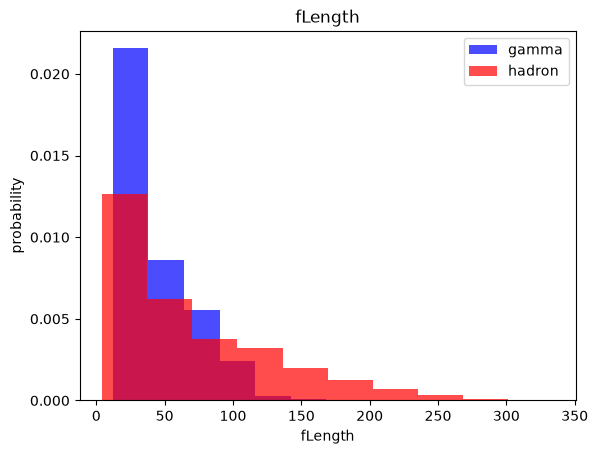

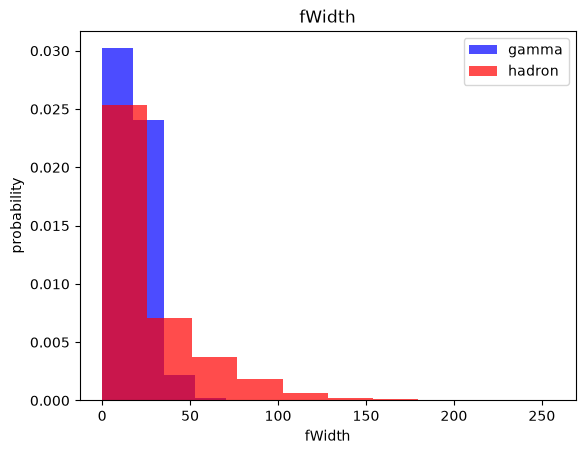

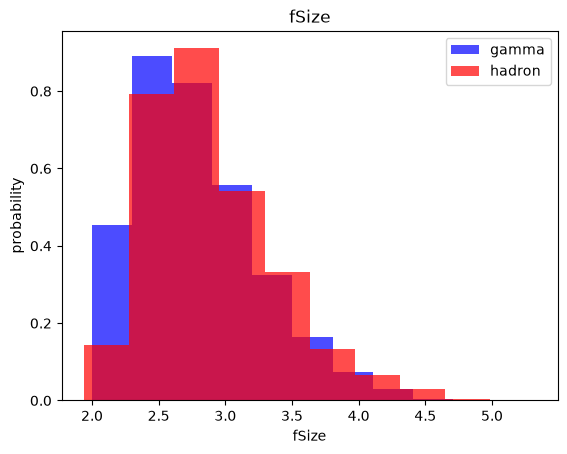

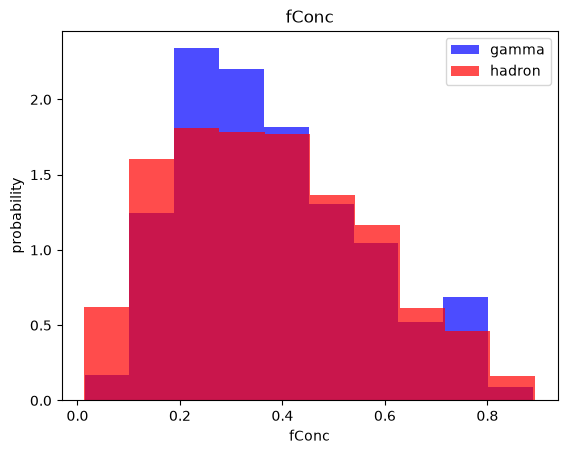

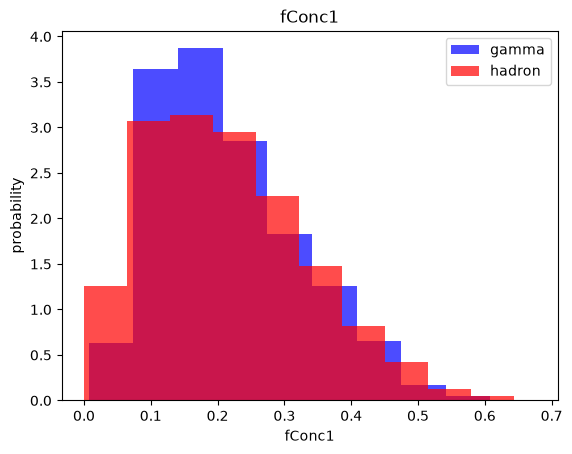

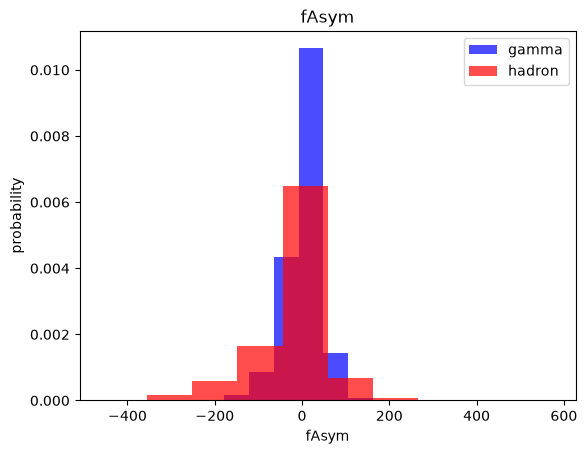

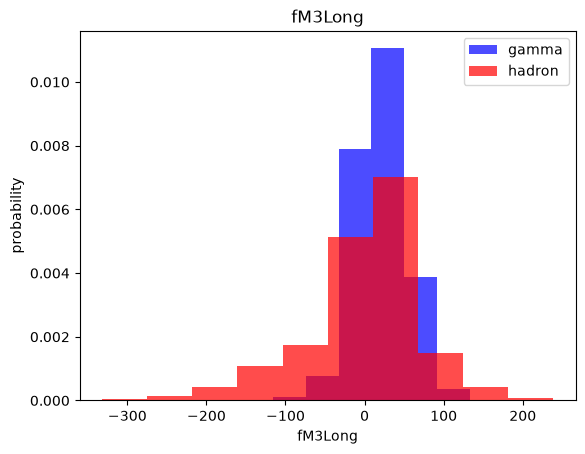

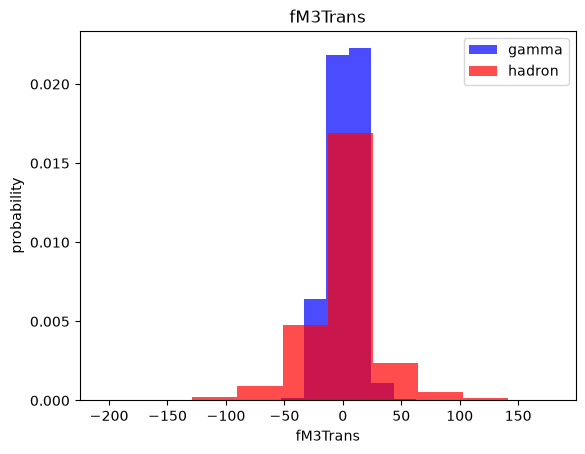

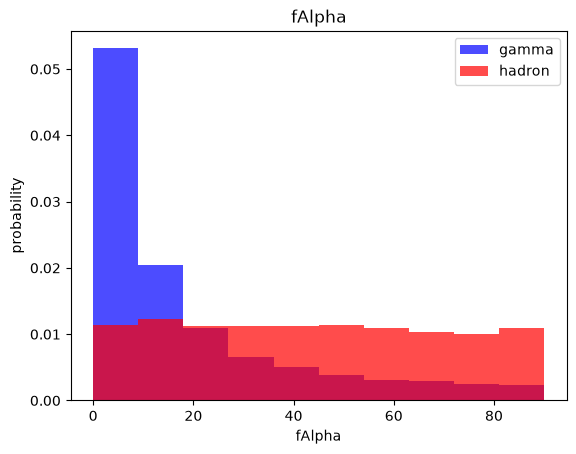

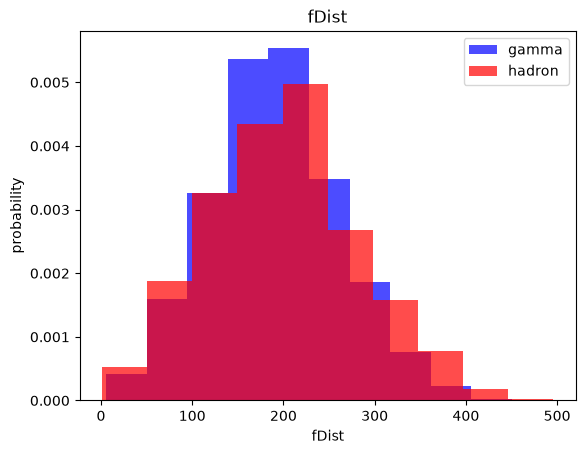

In [6]:
for label in cols[:-1]:
   # [:-1] means get all the value from top except the last item. That is class.
   # because other label is feature(x) while class is target(Y)
  plt.hist(df[df['class'] == 1][label], color="blue", label="gamma", alpha= 0.7, density= True )
  plt.hist(df[df['class'] == 0][label], color="red", label="hadron", alpha= 0.7, density= True )
  plt.title(label)
  plt.ylabel("probability")
  plt.xlabel(label)
  plt.legend() # legend() tells you which line, point, or color represents which data
  plt.show()

# Train, Validate and test datasets

In [7]:
print(len(df))

19020


In [47]:
df = df.sample(frac=1).reset_index(drop=True)
# df.sample(frac=1) shuffles the entire DataFrame randomly.
# frac=1 means we take 100% of the data.
train = df[:int(0.6 * len(df))]
valid = df[int(0.6 * len(df)):int(0.8 * len(df))]
test = df[int(0.8 * len(df)):]
# Our DataFrame has 19,020 rows.
# 0.6 (60%) * 19,020 = 11,412
# So, the first 11,412 rows are used as training data.

# 0.8 (80%) * 19,020 = 15,216
# 15,216 is the second split position, NOT the number of test rows.

# Data between 11,412 and 15,216 is validation data:
# 15,216 - 11,412 = 3,804 rows.

# The remaining data after 15,216 is test data:
# 19,020 - 15,216 = 3,804 rows.

# Dataset       Rows       Percentage
# Training      11,412       60%
# Validation     3,804       20%
# Test           3,804       20%
# Total         19,020      100%

# Visual representation:
#
# 0                         11,412                15,216                 19,020
# │----------------------------│---------------------│----------------------│
#            TRAIN                    VALID                  TEST
#          11,412 rows              3,804 rows             3,804 rows
#             60%                      20%                    20%

In [41]:
def scale_datasets(dataframe, oversample = False):
    x = dataframe[dataframe.columns[:-1]].values 
    y = dataframe[dataframe.columns[-1]].values 
    scalar = StandardScaler()
    x = scalar.fit_transform(x)
    if oversample:
        ros = RandomOverSampler()
        x, y = ros.fit_resample(x, y) # to increase the size of smaller datasets so that they match
    data = np.hstack((x, np.reshape(y, (len(y), 1)))) 
    # hstack() is a method in numpy which takes two array and put them side by side
    # x is 2 dimentional array where y is 1 dimentional array
    return data, x, y

In [48]:
train, x_train, y_train = scale_datasets(train, oversample=True)
valid, x_valid, y_valid = scale_datasets(valid, oversample=False)
test, x_test, y_test = scale_datasets(test, oversample=False)